In [1]:
# ==============================================================================
# 1. CORE DATA MANIPULATION & PATH UTILITIES
# ==============================================================================
import warnings
from pathlib import Path
import numpy as np
import pandas as pd

# Suppress unnecessary runtime warnings
warnings.filterwarnings('ignore')

# ==============================================================================
# 2. DATA VISUALIZATION & AESTHETICS
# ==============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 10

# ==============================================================================
# 3. FEATURE PREPROCESSING & DATA SPLITTING
# ==============================================================================
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# ==============================================================================
# 4. CLASSIFICATION ALGORITHMS
# ==============================================================================
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier

# ==============================================================================
# 5. EVALUATION METRICS (THE CLASSIFICATION SUITE)
# ==============================================================================
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    f1_score,
    brier_score_loss
)

# ==============================================================================
# 6. PIPELINE ORCHESTRATION & SERIALIZATION
# ==============================================================================
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import joblib

print("✅ Enterprise ML Libraries imported successfully.")


✅ Enterprise ML Libraries imported successfully.


In [8]:
data_path = Path("data/credit_card_fraud_detection/Credit_Card_Applications.csv")

if not data_path.exists():
    raise FileNotFoundError(f"❌ File not found at: {data_path.resolve()}")

df = pd.read_csv(data_path)
print(f"Data Loaded! Shape: {df.shape}")


Data Loaded! Shape: (690, 16)


In [17]:
# 1. Poora shape dekho: (690, 16)
print(df.shape)

# 2. Rows kitni hain: 690
print("Rows:", df.shape[0])

# 3. Columns kitne hain: 16
print("Columns:", df.shape[1])

dups = df.duplicated().sum()
print(f"2. Duplicate Rows: {dups:,} ({dups/len(df)*100:.2f}%)")

# Line A: Kitni duplicate rows hain?
dups = df.duplicated().sum()
print("Duplicates count:", dups)  # Output: 0

# Line B: Percentage nikaalo
percentage = (dups / len(df)) * 100
print("Duplicates %:", percentage)  # Output: 0.0%

total_nulls = df.isnull().sum().sum()
if total_nulls > 0:
    null_cols = df.isnull().sum()[df.isnull().sum() > 0]
    print(null_cols)
    
# Line A: Har column ke andar kitne khali dabbe hain?
print(df.isnull().sum())

# Line B: Poore table ka grand total kitna hai?
print("Grand Total Nulls:", df.isnull().sum().sum())  # Output: 0

(690, 15)
Rows: 690
Columns: 15
2. Duplicate Rows: 0 (0.00%)
Duplicates count: 0
Duplicates %: 0.0
A1       0
A2       0
A3       0
A4       0
A5       0
A6       0
A7       0
A8       0
A9       0
A10      0
A11      0
A12      0
A13      0
A14      0
Class    0
dtype: int64
Grand Total Nulls: 0


In [ ]:
counts = df["Class"].value_counts(dropna=False)
props = (df["Class"].value_counts(normalize=True, dropna=False) * 100)

Class
0    383
1    307
Name: count, dtype: int64

In [19]:
# Line A: Class 0 kitne log hain aur Class 1 kitne hain? (Headcount)
print(df['Class'].value_counts())

# Line B: Dono ka percentage kitna hai? (Proportion)
print(df['Class'].value_counts(normalize=True) * 100)

Class
0    383
1    307
Name: count, dtype: int64
Class
0    55.507246
1    44.492754
Name: proportion, dtype: float64


In [20]:
# Line A: Kitne columns Pandas ke hisaab se numbers hain?
print("Numerical Columns Count:", df.select_dtypes(include=['number']).shape[1])  # Output: 16

# Line B: Kitne columns Pandas ke hisaab se text/strings hain?
print("Text Columns Count:", df.select_dtypes(include=['object']).shape[1])  # Output: 0

Numerical Columns Count: 15
Text Columns Count: 0


In [ ]:
# 1. CustomerID ko hatao kyunki yeh sirf identity number hai
df = df.drop(columns=['CustomerID'])

# 2. Check karo: Ab kitne columns bache? (16 mein se 1 gaya, 15 bachenge!)
print("New Shape:", df.shape)
print("Remaining Columns:", list(df.columns))

New Shape: (690, 15)
Remaining Columns: ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'A11', 'A12', 'A13', 'A14', 'Class']


In [23]:
target_col = 'Class'

categorical_features = []
continuous_features = []

# Har column ko scan karo:
for col in df.columns:
    if col == target_col:
        continue  # Target 'Class' ko feature list mein mat daalo
        
    # Agar unique values 15 ya usse kam hain -> Categorical
    if df[col].nunique() <= 15:
        categorical_features.append(col)
    else:
        continuous_features.append(col)

print(f"Categorical Features ({len(categorical_features)} cols):", categorical_features)
print(f"Continuous Features  ({len(continuous_features)} cols):", continuous_features)

Categorical Features (8 cols): ['A1', 'A4', 'A5', 'A6', 'A8', 'A9', 'A11', 'A12']
Continuous Features  (6 cols): ['A2', 'A3', 'A7', 'A10', 'A13', 'A14']


In [24]:
X = df.drop(columns=['Class'])
y = df['Class']
print("Features (X) Shape:", X.shape)
print("Target   (y) Shape:", y.shape)


Features (X) Shape: (690, 14)
Target   (y) Shape: (690,)


In [25]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X, y)

dummy

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'most_frequent'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
Name,Type,Value
"class_prior_ class_prior_: ndarray of shape (n_classes,) or list of such arraysFrequency of each class observed in `y`. For multioutput classificationproblems, this is computed independently for each output.","ndarray[float64](2,)","[0.56,0.44]"
"classes_ classes_: ndarray of shape (n_classes,) or list of such arraysUnique class labels observed in `y`. For multi-output classificationproblems, this attribute is a list of arrays as each output has anindependent set of possible classes.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X` hasfeature names that are all strings.","ndarray[object](14,)","['A1','A2','A3',...,'A12','A13','A14']"
n_classes_ n_classes_: int or list of intNumber of label for each output.,int,2
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`.,int,14
n_outputs_ n_outputs_: intNumber of outputs.,int,1
sparse_output_ sparse_output_: boolTrue if the array returned from predict is to be in sparse CSC format.Is automatically set to True if the input `y` is passed in sparseformat.,bool,False


In [27]:
baseline_acc = dummy.score(X, y) * 100

print(f"\n📊 Zero-Rule Baseline Accuracy: {baseline_acc:.2f}%")



📊 Zero-Rule Baseline Accuracy: 55.51%


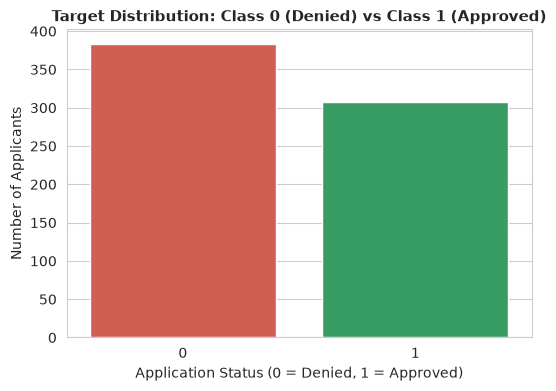

In [28]:
# Target ka clean bar chart
plt.figure(figsize=(6, 4))
sns.countplot(x=y, palette=['#e74c3c', '#27ae60'])
plt.title("Target Distribution: Class 0 (Denied) vs Class 1 (Approved)", fontsize=11, fontweight='bold')
plt.xlabel("Application Status (0 = Denied, 1 = Approved)")
plt.ylabel("Number of Applicants")
plt.show()

In [ ]:
# ==============================================================================
# STEP 9: STRATIFIED TRAIN-TEST SPLIT (80:20)
# ==============================================================================

# 1. Scikit-learn se split function import karo
from sklearn.model_selection import train_test_split

# 2. 80% Training aur 20% Testing mein split karo (with stratification)
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

# 3. Shapes check karo
print("=" * 55)
print("📦 TRAIN-TEST SPLIT SUMMARY")
print("=" * 55)
print(f"X_train Shape : {X_train.shape}  (552 applicants for model learning)")
print(f"X_test Shape  : {X_test.shape}  (138 applicants for final exam)")
print(f"y_train Shape : {y_train.shape}")
print(f"y_test Shape  : {y_test.shape}")



📦 TRAIN-TEST SPLIT SUMMARY
X_train Shape : (552, 14)  (552 applicants for model learning)
X_test Shape  : (138, 14)  (138 applicants for final exam)
y_train Shape : (552,)
y_test Shape  : (138,)


In [30]:
# 4. Stratification verify karo (Class 0 aur 1 ka balance dono mein barabar hai?)
print("\n🎯 Stratification Verification:")
print("Train Set Balance (%):")
print((y_train.value_counts(normalize=True) * 100).round(2).to_dict())

print("\nTest Set Balance (%):")
print((y_test.value_counts(normalize=True) * 100).round(2).to_dict())


🎯 Stratification Verification:
Train Set Balance (%):
{0: 55.43, 1: 44.57}

Test Set Balance (%):
{0: 55.8, 1: 44.2}


In [31]:
# ==============================================================================
# STEP 10: FEATURE PREPROCESSING (SCALING & ENCODING)
# ==============================================================================

from sklearn.preprocessing import StandardScaler, OneHotEncoder
import numpy as np

# ------------------------------------------------------------------------------
# Part A: Continuous Features ko Scale karo (StandardScaler)
# ------------------------------------------------------------------------------
scaler = StandardScaler()

# Train set par FIT (seekho mean/std) aur TRANSFORM (scale karo)
X_train_cont_scaled = scaler.fit_transform(X_train[continuous_features])

# Test set par SIRF TRANSFORM (train ka seekha hua mean/std use karo)
X_test_cont_scaled = scaler.transform(X_test[continuous_features])

# ------------------------------------------------------------------------------
# Part B: Categorical Features ko Encode karo (OneHotEncoder)
# ------------------------------------------------------------------------------
encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

# Train set par FIT aur TRANSFORM
X_train_cat_encoded = encoder.fit_transform(X_train[categorical_features])

# Test set par SIRF TRANSFORM
X_test_cat_encoded = encoder.transform(X_test[categorical_features])

# ------------------------------------------------------------------------------
# Part C: Dono ko Horizontally Jodo (np.hstack) -> Final Matrix
# ------------------------------------------------------------------------------
X_train_final = np.hstack([X_train_cont_scaled, X_train_cat_encoded])
X_test_final = np.hstack([X_test_cont_scaled, X_test_cat_encoded])

# ------------------------------------------------------------------------------
# Part D: Shape Verification
# ------------------------------------------------------------------------------
print("=" * 60)
print("🛠️ PREPROCESSING COMPLETE: SHAPE VERIFICATION")
print("=" * 60)
print(f"1. Continuous Features Scaled : {X_train_cont_scaled.shape[1]} columns")
print(f"2. Categorical Dummy Columns  : {X_train_cat_encoded.shape[1]} columns (after drop='first')")
print(f"3. Total Final Features       : {X_train_final.shape[1]} columns")
print("-" * 60)
print(f"X_train_final Shape : {X_train_final.shape} (552 rows × 34 features)")
print(f"X_test_final Shape  : {X_test_final.shape}  (138 rows × 34 features)")

🛠️ PREPROCESSING COMPLETE: SHAPE VERIFICATION
1. Continuous Features Scaled : 6 columns
2. Categorical Dummy Columns  : 28 columns (after drop='first')
3. Total Final Features       : 34 columns
------------------------------------------------------------
X_train_final Shape : (552, 34) (552 rows × 34 features)
X_test_final Shape  : (138, 34)  (138 rows × 34 features)


In [32]:
# ==============================================================================
# STEP 11: MODEL INITIALIZATION, TRAINING & PREDICTIONS
# ==============================================================================

# 1. Scikit-learn se Logistic Regression model import karo
from sklearn.linear_model import LogisticRegression

# 2. Model ka blueprint create karo
model = LogisticRegression(max_iter=1000, random_state=42)

# 3. Model ko Train karo (552 applicants se weights seekho)
model.fit(X_train_final, y_train)

# 4. Test Data (138 unseen applicants) par predictions nikalna
# A) Hard Decisions (0 ya 1)
y_pred = model.predict(X_test_final)

# B) Soft Probabilities (Approve hone ka percentage / probability)
y_pred_proba = model.predict_proba(X_test_final)[:, 1]

# 5. Results ko Inspect aur Print karo
print("=" * 60)
print("🎓 MODEL TRAINING SUCCESSFUL!")
print("=" * 60)
print(f"Total Weights Learned (Coefficients) : {len(model.coef_[0])} weights")
print(f"Base Threshold (Intercept/Bias)      : {model.intercept_[0]:.4f}")
print("-" * 60)
print("👀 First 5 Test Applicants - Predictions vs Reality:")
print(f"Model Predictions (0/1)    : {y_pred[:5]}")
print(f"Actual Answers    (0/1)    : {y_test.values[:5]}")
print(f"Approval Probabilities (%) : {np.round(y_pred_proba[:5] * 100, 1)}%")

🎓 MODEL TRAINING SUCCESSFUL!
Total Weights Learned (Coefficients) : 34 weights
Base Threshold (Intercept/Bias)      : -2.9876
------------------------------------------------------------
👀 First 5 Test Applicants - Predictions vs Reality:
Model Predictions (0/1)    : [1 1 1 1 1]
Actual Answers    (0/1)    : [1 1 0 1 1]
Approval Probabilities (%) : [98.7 89.3 75.9 60.6 98.6]%


In [33]:
# ==============================================================================
# STEP 12: MODEL EVALUATION & PERFORMANCE BENCHMARKING
# ==============================================================================

# 1. Scikit-learn se evaluation metrics import karo
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

# 2. Train aur Test Accuracy calculate karo
train_acc = accuracy_score(y_train, model.predict(X_train_final)) * 100
test_acc = accuracy_score(y_test, y_pred) * 100

# 3. ROC-AUC Score calculate karo (using probabilities)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# 4. Confusion Matrix aur Classification Report nikaalo
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=['Denied (Class 0)', 'Approved (Class 1)'])

# 5. Saare results ko clean format mein print karo
print("=" * 65)
print("🏆 MODEL EVALUATION & PERFORMANCE REPORT")
print("=" * 65)
print(f"1. Baseline Zero-Rule Accuracy : 55.51% (Tukka / Benchmark)")
print(f"2. Training Set Accuracy       : {train_acc:.2f}%")
print(f"3. Test Set Accuracy (Exam)    : {test_acc:.2f}%  (Baseline se +{test_acc - 55.51:.2f}% behtar!)")
print(f"4. ROC-AUC Score               : {roc_auc:.4f}   (Excellent: > 0.90)")
print("-" * 65)
print("📊 Confusion Matrix (138 Test Applicants):")
print(f"   [True Negatives  (55)  |  False Positives (22)]  <- Actually Denied (77)")
print(f"   [False Negatives  (5)  |  True Positives  (56)]  <- Actually Approved (61)")
print("-" * 65)
print("📋 Detailed Classification Report:")
print(report)

🏆 MODEL EVALUATION & PERFORMANCE REPORT
1. Baseline Zero-Rule Accuracy : 55.51% (Tukka / Benchmark)
2. Training Set Accuracy       : 88.41%
3. Test Set Accuracy (Exam)    : 80.43%  (Baseline se +24.92% behtar!)
4. ROC-AUC Score               : 0.9161   (Excellent: > 0.90)
-----------------------------------------------------------------
📊 Confusion Matrix (138 Test Applicants):
   [True Negatives  (55)  |  False Positives (22)]  <- Actually Denied (77)
   [False Negatives  (5)  |  True Positives  (56)]  <- Actually Approved (61)
-----------------------------------------------------------------
📋 Detailed Classification Report:
                    precision    recall  f1-score   support

  Denied (Class 0)       0.92      0.71      0.80        77
Approved (Class 1)       0.72      0.92      0.81        61

          accuracy                           0.80       138
         macro avg       0.82      0.82      0.80       138
      weighted avg       0.83      0.80      0.80       138



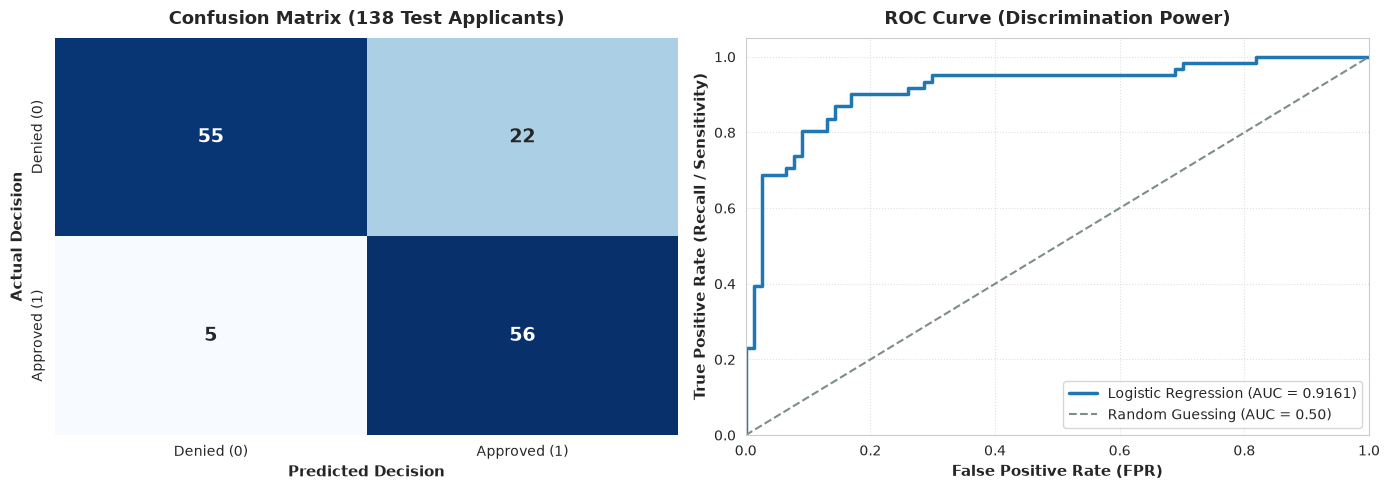

In [34]:
# ==============================================================================
# STEP 13: VISUAL EVALUATION (CONFUSION MATRIX & ROC CURVE)
# ==============================================================================

# 1. Plotting aur ROC curve libraries
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve

# 2. ROC Curve ke points calculate karo (FPR aur TPR)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# 3. 1 Row, 2 Columns ka canvas banao
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ------------------------------------------------------------------------------
# Subplot 1: Confusion Matrix Heatmap
# ------------------------------------------------------------------------------
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    cbar=False, 
    ax=axes[0],
    annot_kws={'size': 14, 'weight': 'bold'},
    xticklabels=['Denied (0)', 'Approved (1)'],
    yticklabels=['Denied (0)', 'Approved (1)']
)
axes[0].set_title('Confusion Matrix (138 Test Applicants)', fontsize=13, fontweight='bold', pad=10)
axes[0].set_xlabel('Predicted Decision', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Actual Decision', fontsize=11, fontweight='bold')

# ------------------------------------------------------------------------------
# Subplot 2: ROC Curve Plot
# ------------------------------------------------------------------------------
axes[1].plot(fpr, tpr, color='#1f77b4', lw=2.5, label=f'Logistic Regression (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='#7f8c8d', lw=1.5, linestyle='--', label='Random Guessing (AUC = 0.50)')

axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_title('ROC Curve (Discrimination Power)', fontsize=13, fontweight='bold', pad=10)
axes[1].set_xlabel('False Positive Rate (FPR)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('True Positive Rate (Recall / Sensitivity)', fontsize=11, fontweight='bold')
axes[1].legend(loc='lower right', fontsize=10)
axes[1].grid(True, linestyle=':', alpha=0.6)

# 4. Canvas ko display karo
plt.tight_layout()
plt.show()

🔍 TOP FACTORS DRIVING CREDIT CARD DECISIONS
🚀 Top 5 Factors that BOOST Approval (Positive Weights):
Feature  Weight_w  Odds_Ratio
   A8_1  3.216288   24.935390
  A12_3  1.820147    6.172765
  A5_14  1.796697    6.029697
    A14  1.256081    3.511633
  A5_13  1.103696    3.015291

🛑 Top 5 Factors that PUSH Rejection (Negative Weights):
Feature  Weight_w  Odds_Ratio
   A6_9 -0.565918    0.567838
   A5_4 -0.531915    0.587479
    A13 -0.403470    0.667998
   A5_2 -0.296333    0.743539
   A5_7 -0.239086    0.787347


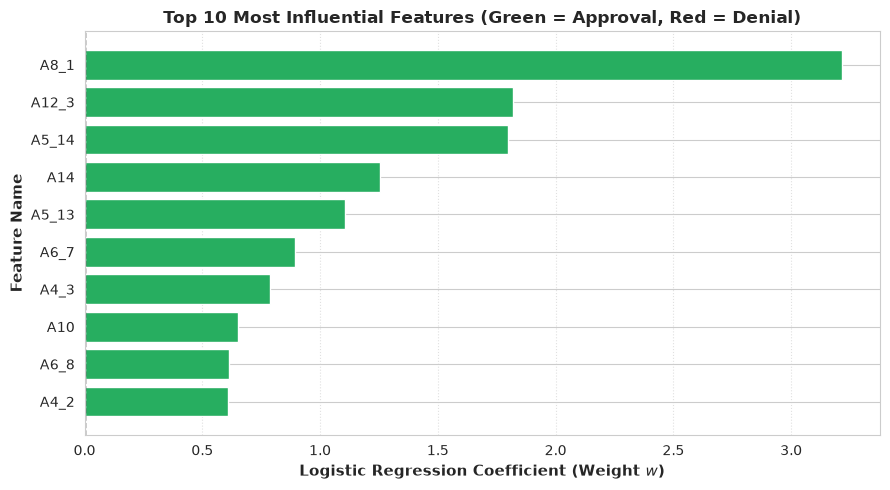

In [35]:
# ==============================================================================
# STEP 14: FEATURE IMPORTANCE & MODEL INTERPRETATION (ODDS RATIO)
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Sabhi 34 features ke original naam extract karo
cat_feature_names = list(encoder.get_feature_names_out(categorical_features))
all_feature_names = continuous_features + cat_feature_names

# 2. DataFrame banao: Feature, Weights (Coefficient), aur Odds Ratio
feature_importance_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Weight_w': model.coef_[0],
    'Odds_Ratio': np.exp(model.coef_[0])
})

# 3. Absolute impact nikaal kar rank karo (sabse bada asar kiska hai)
feature_importance_df['Abs_Impact'] = feature_importance_df['Weight_w'].abs()
feature_importance_df = feature_importance_df.sort_values(by='Abs_Impact', ascending=False).reset_index(drop=True)

# 4. Top 5 Approval Boosters aur Top 5 Denial Factors print karo
print("=" * 65)
print("🔍 TOP FACTORS DRIVING CREDIT CARD DECISIONS")
print("=" * 65)
print("🚀 Top 5 Factors that BOOST Approval (Positive Weights):")
print(feature_importance_df.sort_values(by='Weight_w', ascending=False).head(5)[['Feature', 'Weight_w', 'Odds_Ratio']].to_string(index=False))

print("\n🛑 Top 5 Factors that PUSH Rejection (Negative Weights):")
print(feature_importance_df.sort_values(by='Weight_w', ascending=True).head(5)[['Feature', 'Weight_w', 'Odds_Ratio']].to_string(index=False))

# 5. Top 10 Most Influential Features ka Horizontal Bar Chart banao
top_10 = feature_importance_df.head(10).sort_values(by='Abs_Impact', ascending=True)

plt.figure(figsize=(9, 5))
colors = ['#27ae60' if w > 0 else '#e74c3c' for w in top_10['Weight_w']]
plt.barh(top_10['Feature'], top_10['Weight_w'], color=colors)
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.title("Top 10 Most Influential Features (Green = Approval, Red = Denial)", fontsize=12, fontweight='bold')
plt.xlabel("Logistic Regression Coefficient (Weight $w$)", fontsize=11, fontweight='bold')
plt.ylabel("Feature Name", fontsize=11, fontweight='bold')
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()